In [1]:
##### Calculate the dissimilarity index and AIA for each pixel in raster against capital and labor model training data

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import rasterio
import rioxarray as rio
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle


In [8]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import predictors data
capital_model = pd.read_csv(f"{cd}/Data/Clean/Training_data/capital_relative_final_thinned.csv")
labor_model = pd.read_csv(f"{cd}/Data/Clean/Training_data/labor_relative_final_thinned.csv")
raster_model = pd.read_parquet(f"{cd}/Data/Clean/Training_data/raster_predictor_matrix_relative.parquet")

# Import fold assignments 
fold_cap = pd.read_csv(f"{cd}/Data/Fold_assignments/capital_folds.csv")
fold_lab = pd.read_csv(f"{cd}/Data/Fold_assignments/labor_folds.csv")

# Import feature importance 
imp_cap_df = pd.read_csv(f"{cd}/Results/RF_models_final/capital_rf_spatial_CV/feature_importance.csv")
imp_lab_df = pd.read_csv(f"{cd}/Results/RF_models_final/labor_rf_spatial_CV/feature_importance.csv")

# reference raster
ref_path = f"{cd}/Data/Clean/Production/total_production_tonnes_2020.tif"

# country boundaries 
country_boundaries = gpd.read_file(f"{cd}/Data/Clean/Geographies/country_geo.shp")

has_data = pd.read_csv(f'{cd}/Data/Correspondence_tables/has_data.csv')

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/transferability_metric"

In [9]:
##### Add CV fold assignments to capital and labor model data

def wide_folds_to_fold_id(fold_df, id_col='country_ID'):
    fold_cols = [c for c in fold_df.columns if c.startswith('fold_')]
    n_flags = fold_df[fold_cols].sum(axis=1)
    fold_id = fold_df[fold_cols].values.argmax(axis=1) + 1
    out = fold_df[[id_col]].copy()
    out['fold_id'] = fold_id
    return out

fold_id_cap = wide_folds_to_fold_id(fold_cap)
fold_id_lab = wide_folds_to_fold_id(fold_lab)

# extract country_ID from PROJ_ID (e.g. "USA_HA_01234" -> "USA")
capital_model['country_ID'] = capital_model['PROJ_ID'].astype(str).str[:3]
labor_model['country_ID'] = labor_model['PROJ_ID'].astype(str).str[:3]

capital_model = capital_model.merge(fold_id_cap, on='country_ID', how='left')
labor_model = labor_model.merge(fold_id_lab, on='country_ID', how='left')

In [10]:
##### Identify no data countries 

country_boundaries = country_boundaries.merge(has_data, on='SHP_code', how='left')
country_boundaries['has_capital_data'] = country_boundaries['has_capital_data'].fillna(0)
country_boundaries['has_labor_data'] = country_boundaries['has_labor_data'].fillna(0)

#### Calculate dissimilarity index

In [11]:
#### Map columns across models and raster

# all columns (using model names) 
capital_cols = ['rtv_log_average_travel_time_port',
       'rtv_log_crop_intensity',
       'rtv_log_USD_production_per_million_HA',
       'rtv_log_tonnes_production_per_million_HA',
       'rtv_log_pop_density_people_per_100_km2',
       'rtv_log_cattle_density_per_100_km2',
       'rtv_log_sheep_density_per_100_km2',
       'rtv_log_livestock_density_LU_per_100_km2',
       'rtv_log_cereals_share_base_100_production_tonnes',
       'rtv_log_fruits_share_base_100_production_tonnes',
       'rtv_log_roots_tubers_share_base_100_production_tonnes',
       'rtv_log_vegetables_share_base_100_production_tonnes',
       'rtv_log_ruminants_share_base_100_production_tonnes',
       'rtv_log_share_base_100_large_field',
       'rtv_log_share_base_100_with_nightlights']

labor_cols = ['rtv_log_average_travel_time_port',
       'rtv_log_crop_intensity',
       'rtv_log_pop_density_people_per_100_km2',
       'rtv_log_cattle_density_per_100_km2',
       'rtv_log_livestock_density_LU_per_100_km2',
       'rtv_log_fruits_share_base_100_production_tonnes',
       'rtv_log_roots_tubers_share_base_100_production_tonnes',
       'rtv_log_rest_of_crops_share_base_100_production_tonnes',
       'rtv_log_sugar_crops_share_base_100_production_tonnes',
       'rtv_log_ruminants_share_base_100_production_tonnes',
       'rtv_log_pct_base_100_GDP_ag', 'rtv_log_share_base_100_large_field',
       'rtv_log_pct_base_100_cropland_irrigated']

In [12]:
#### Prep data

# pull predictor + fold data together so rows stay aligned after dropna
X_train_lab_full = labor_model[labor_cols + ['fold_id']].dropna()
X_train_lab = X_train_lab_full[labor_cols]
fold_ids_lab = X_train_lab_full['fold_id'].values

X_train_cap_full = capital_model[capital_cols + ['fold_id']].dropna()
X_train_cap = X_train_cap_full[capital_cols]
fold_ids_cap = X_train_cap_full['fold_id'].values

X_pixel_raw_lab = raster_model[labor_cols]
X_pixel_raw_cap = raster_model[capital_cols]

# mask to only include pixels with full data
valid_mask_lab = X_pixel_raw_lab.notna().all(axis=1)
valid_mask_cap = X_pixel_raw_cap.notna().all(axis=1)

# rescale predictors to 0 = mean SD = 1 (puts on comparable scale)
scaler = StandardScaler()

X_train_scaled_lab = scaler.fit_transform(X_train_lab)
X_pixel_scaled_lab = scaler.transform(X_pixel_raw_lab[valid_mask_lab])

scaler_cap = StandardScaler()  # separate scaler instance, since capital/labor have different cols
X_train_scaled_cap = scaler_cap.fit_transform(X_train_cap)
X_pixel_scaled_cap = scaler_cap.transform(X_pixel_raw_cap[valid_mask_cap])

##### Apply variable importance weighting (Meyer & Pebesma, 2021, Section 2.2)

imp_lab_map = imp_lab_df.set_index('feature')['permutation_mean'].to_dict()
imp_cap_map = imp_cap_df.set_index('feature')['permutation_mean'].to_dict()

importance_lab = np.array([imp_lab_map[c] for c in labor_cols])
importance_cap = np.array([imp_cap_map[c] for c in capital_cols])

X_train_scaled_lab = X_train_scaled_lab * importance_lab
X_pixel_scaled_lab = X_pixel_scaled_lab * importance_lab

X_train_scaled_cap = X_train_scaled_cap * importance_cap
X_pixel_scaled_cap = X_pixel_scaled_cap * importance_cap

In [13]:
#### Calculate dissimilarity index for each pixel (Meyer & Pebesma, 2021)
# only need to re-run if underlying data has changed

def cross_fold_nn_distance(X_scaled, fold_ids):
    """
    For each training point, find the distance to its nearest neighbor
    among training points NOT in the same CV fold (Meyer & Pebesma 2021,
    Section 2.5) — needed for the AOA threshold
    """
    dists = np.full(len(X_scaled), np.nan)
    fold_ids = np.asarray(fold_ids)
    for fold in np.unique(fold_ids):
        held_out_mask = fold_ids == fold
        pool_mask = ~held_out_mask  # everything not in this fold

        nn = NearestNeighbors(n_neighbors=1, n_jobs=-1)
        nn.fit(X_scaled[pool_mask])
        d, _ = nn.kneighbors(X_scaled[held_out_mask])
        dists[held_out_mask] = d[:, 0]
    return dists

# --- Normalization factor (left as-is: mean nearest-neighbor distance, unrestricted by fold) ---
nn_train_lab = NearestNeighbors(n_neighbors=2, n_jobs=-1)
nn_train_lab.fit(X_train_scaled_lab)
train_nn_dists_lab, _ = nn_train_lab.kneighbors(X_train_scaled_lab)
avg_train_nn_dist_lab = train_nn_dists_lab[:, 1].mean()

nn_train_cap = NearestNeighbors(n_neighbors=2, n_jobs=-1)
nn_train_cap.fit(X_train_scaled_cap)
train_nn_dists_cap, _ = nn_train_cap.kneighbors(X_train_scaled_cap)
avg_train_nn_dist_cap = train_nn_dists_cap[:, 1].mean()

# --- Pixel-level DI: nearest training point, no fold restriction (pixels aren't in any fold) ---
nn_lab = NearestNeighbors(n_neighbors=1, n_jobs=-1)
nn_lab.fit(X_train_scaled_lab)
pixel_nn_dists_lab, _ = nn_lab.kneighbors(X_pixel_scaled_lab)
pixel_nn_dists_lab = pixel_nn_dists_lab[:, 0]
DI_lab = pixel_nn_dists_lab / avg_train_nn_dist_lab

nn_cap = NearestNeighbors(n_neighbors=1, n_jobs=-1)
nn_cap.fit(X_train_scaled_cap)
pixel_nn_dists_cap, _ = nn_cap.kneighbors(X_pixel_scaled_cap)
pixel_nn_dists_cap = pixel_nn_dists_cap[:, 0]
DI_cap = pixel_nn_dists_cap / avg_train_nn_dist_cap

# --- AOA threshold: DI of training data using CROSS-FOLD-RESTRICTED nearest neighbor ---
train_cross_fold_dists_lab = cross_fold_nn_distance(X_train_scaled_lab, fold_ids_lab)
train_di_lab = train_cross_fold_dists_lab / avg_train_nn_dist_lab
q25_lab, q75_lab = np.percentile(train_di_lab, [25, 75])
aoa_threshold_lab = q75_lab + 1.5 * (q75_lab - q25_lab)

train_cross_fold_dists_cap = cross_fold_nn_distance(X_train_scaled_cap, fold_ids_cap)
train_di_cap = train_cross_fold_dists_cap / avg_train_nn_dist_cap
q25_cap, q75_cap = np.percentile(train_di_cap, [25, 75])
aoa_threshold_cap = q75_cap + 1.5 * (q75_cap - q25_cap)

In [14]:
### Assemble output
# only neeed to re-run if underlying data has changed

# get x,y of pixel  
output_df = raster_model[['x', 'y']].copy()

# initialize columns 
output_df['DI_lab'] = np.nan
output_df['within_AOA_lab'] = np.nan

output_df['DI_cap'] = np.nan
output_df['within_AOA_cap'] = np.nan

# add in DI and binary measure of within AOA for each pixel 
output_df.loc[valid_mask_lab, 'DI_lab'] = DI_lab
output_df.loc[valid_mask_lab, 'within_AOA_lab'] = (DI_lab <= aoa_threshold_lab).astype(int)

output_df.loc[valid_mask_cap, 'DI_cap'] = DI_cap
output_df.loc[valid_mask_cap, 'within_AOA_cap'] = (DI_cap <= aoa_threshold_cap).astype(int)

output_df.to_csv(f"{fd}/DI_AOA_calcs.csv", index=False)

In [15]:
### Convert back to raster to plot (LABOR)

output_df = pd.read_csv(f"{fd}/DI_AOA_calcs.csv")

# get metadata from raster
with rasterio.open(ref_path) as src:
    profile = src.profile
    height  = src.height
    width   = src.width
    transform = src.transform

# start with empty aray in correct format
di_grid  = np.full((height, width), np.nan, dtype=np.float32)
aoa_grid = np.full((height, width), np.nan, dtype=np.float32)

# map x/y coordinates back to arrary using row/column indicies 
rows, cols = rasterio.transform.rowcol(
    transform,
    output_df['x'].values,
    output_df['y'].values
)
rows = np.array(rows)
cols = np.array(cols)

# fill with DI and AOA values (only for pixels that aren't missing values)
valid = output_df['DI_lab'].notna().values
di_grid[rows[valid], cols[valid]]  = output_df.loc[valid, 'DI_lab'].values
aoa_grid[rows[valid], cols[valid]] = output_df.loc[valid, 'within_AOA_lab'].values

# Save as tiffs
profile.update(dtype='float32', count=1, nodata=np.nan)

with rasterio.open(f'{fd}/DI_labor.tif', 'w', **profile) as dst:
    dst.write(di_grid, 1)

with rasterio.open(f'{fd}/AOA_labor.tif', 'w', **profile) as dst:
    dst.write(aoa_grid, 1)

In [16]:
### Convert back to raster to plot (CAPITAL)

output_df = pd.read_csv(f"{fd}/DI_AOA_calcs.csv")

# get metadata from raster
with rasterio.open(ref_path) as src:
    profile = src.profile
    height  = src.height
    width   = src.width
    transform = src.transform

# start with empty aray in correct format
di_grid  = np.full((height, width), np.nan, dtype=np.float32)
aoa_grid = np.full((height, width), np.nan, dtype=np.float32)

# map x/y coordinates back to arrary using row/column indicies 
rows, cols = rasterio.transform.rowcol(
    transform,
    output_df['x'].values,
    output_df['y'].values
)
rows = np.array(rows)
cols = np.array(cols)

# fill with DI and AOA values (only for pixels that aren't missing values)
valid = output_df['DI_cap'].notna().values
di_grid[rows[valid], cols[valid]]  = output_df.loc[valid, 'DI_cap'].values
aoa_grid[rows[valid], cols[valid]] = output_df.loc[valid, 'within_AOA_cap'].values

# Save as tiffs
profile.update(dtype='float32', count=1, nodata=np.nan)

with rasterio.open(f'{fd}/DI_capital.tif', 'w', **profile) as dst:
    dst.write(di_grid, 1)

with rasterio.open(f'{fd}/AOA_capital.tif', 'w', **profile) as dst:
    dst.write(aoa_grid, 1)

In [17]:
##### Decompose DI into per-predictor contributions

def decompose_di(X_pixel_scaled, X_train_scaled, nn_model, feature_names, aoa_mask=None):
    """
    Returns a table of each predictor's average share of the squared
    nearest-neighbor distance, optionally restricted to pixels outside
    the area of applicability (the ones actually driving unreliable predictions).
    """
    dists, idx = nn_model.kneighbors(X_pixel_scaled)
    idx = idx[:, 0]

    matched_train = X_train_scaled[idx]
    sq_diffs = (X_pixel_scaled - matched_train) ** 2  # per-pixel, per-feature

    if aoa_mask is not None:
        sq_diffs = sq_diffs[aoa_mask]

    total_sq_dist = sq_diffs.sum(axis=1, keepdims=True)
    contrib_pct = sq_diffs / total_sq_dist  # each pixel's contributions sum to 1

    table = pd.DataFrame({
        'predictor': feature_names,
        'mean_pct_contribution': contrib_pct.mean(axis=0) * 100,
        'median_pct_contribution': np.median(contrib_pct, axis=0) * 100,
    }).sort_values('mean_pct_contribution', ascending=False).reset_index(drop=True)

    return table

# All pixels
contrib_table_lab = decompose_di(X_pixel_scaled_lab, X_train_scaled_lab, nn_lab, labor_cols)
contrib_table_cap = decompose_di(X_pixel_scaled_cap, X_train_scaled_cap, nn_cap, capital_cols)

# Restricted to pixels OUTSIDE the area of applicability — usually the more useful table,
# since these are the pixels whose predictions you'd actually flag as unreliable
outside_aoa_lab = DI_lab > aoa_threshold_lab
outside_aoa_cap = DI_cap > aoa_threshold_cap

contrib_table_lab_aoa = decompose_di(
    X_pixel_scaled_lab, X_train_scaled_lab, nn_lab, labor_cols, aoa_mask=outside_aoa_lab
)
contrib_table_cap_aoa = decompose_di(
    X_pixel_scaled_cap, X_train_scaled_cap, nn_cap, capital_cols, aoa_mask=outside_aoa_cap
)

print("Labor model — predictors driving dissimilarity (outside AOA):")
print(contrib_table_lab_aoa)

print("\nCapital model — predictors driving dissimilarity (outside AOA):")
print(contrib_table_cap_aoa)

contrib_table_lab_aoa.to_csv(f"{fd}/DI_predictor_contributions_labor.csv", index=False)
contrib_table_cap_aoa.to_csv(f"{fd}/DI_predictor_contributions_capital.csv", index=False)

Labor model — predictors driving dissimilarity (outside AOA):
                                            predictor  mean_pct_contribution  \
0              rtv_log_pop_density_people_per_100_km2              42.297815   
1   rtv_log_ruminants_share_base_100_production_to...              13.710414   
2                  rtv_log_cattle_density_per_100_km2              10.954098   
3            rtv_log_livestock_density_LU_per_100_km2               9.263416   
4                  rtv_log_share_base_100_large_field               6.665464   
5   rtv_log_roots_tubers_share_base_100_production...               4.793212   
6     rtv_log_fruits_share_base_100_production_tonnes               3.992347   
7             rtv_log_pct_base_100_cropland_irrigated               2.780407   
8   rtv_log_sugar_crops_share_base_100_production_...               1.822566   
9                         rtv_log_pct_base_100_GDP_ag               1.593956   
10  rtv_log_rest_of_crops_share_base_100_productio...     

#### Plot dissimilarity index

In [18]:
##### Prep data

# load data
di_grid_labor = rio.open_rasterio(f'{fd}/DI_labor.tif')
di_grid_capital = rio.open_rasterio(f'{fd}/DI_capital.tif')
production = rio.open_rasterio(ref_path)

# align crs
crs = "+proj=eck4 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
di_grid_labor = di_grid_labor.rio.reproject(crs)
di_grid_capital = di_grid_capital.rio.reproject(crs)
production = production.rio.reproject(crs)  

country_boundaries = country_boundaries.to_crs(crs)

# filter to only pixels with produciton (only ones where model actually makes prediction)

production = production.rio.reproject_match(di_grid_capital)

# Mask nodata/fill values introduced by reprojection
di_grid_capital = di_grid_capital.where(di_grid_capital > 0)
di_grid_labor = di_grid_labor.where(di_grid_labor > 0)

di_plot_capital = di_grid_capital.squeeze()
di_grid_labor = di_grid_labor.squeeze()

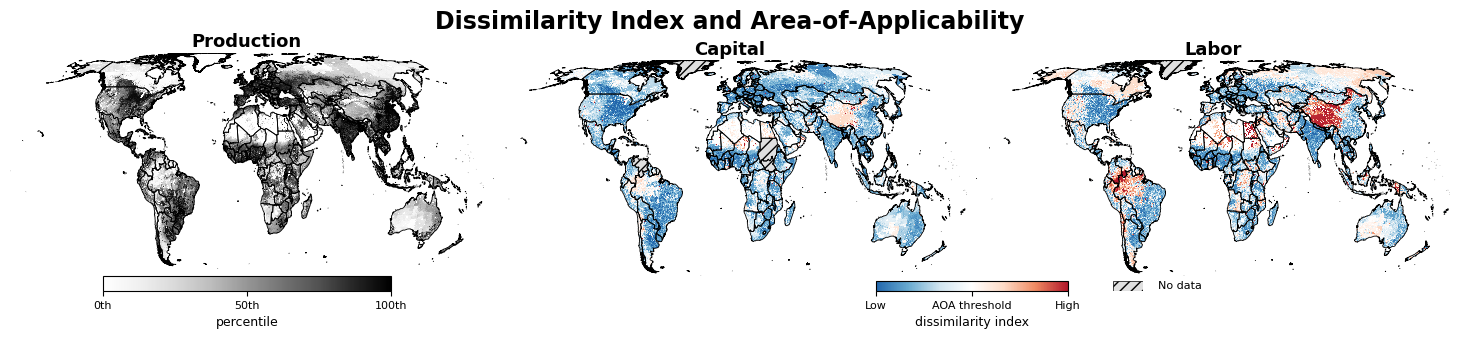

In [37]:
##### Prep production data (percentile-ranked, aligned to same grid as DI panels)

production = rio.open_rasterio(ref_path)
production = production.rio.reproject(crs)
production = production.rio.reproject_match(di_grid_capital)  # match extent/resolution to DI grids

production_masked = production.where(production > 0).squeeze()

# convert to percentile rank (0-100) over valid pixels only
prod_vals = production_masked.values
valid_prod = np.isfinite(prod_vals)

from scipy.stats import rankdata
prod_percentile = np.full(prod_vals.shape, np.nan)
prod_percentile[valid_prod] = rankdata(prod_vals[valid_prod], method='average') / valid_prod.sum() * 100

production_percentile = production_masked.copy(data=prod_percentile)

##### Global side-by-side map: production percentile (left), DI relative to AOA threshold, capital (middle) vs labor (right)

# Express DI as a ratio to each model's own AOA threshold, so 1.0 always means
# "right at the threshold" regardless of the model-specific threshold value.
# This lets both DI panels share one colorbar/legend even though aoa_threshold_cap
# and aoa_threshold_lab differ numerically.

di_ratio_capital = di_grid_capital / aoa_threshold_cap
di_ratio_labor = di_grid_labor / aoa_threshold_lab

combined_ratios = np.concatenate([
    di_ratio_capital.values[np.isfinite(di_ratio_capital.values)],
    di_ratio_labor.values[np.isfinite(di_ratio_labor.values)],
])

ratio_vmin = np.percentile(combined_ratios, 1)
ratio_cap_max = np.percentile(combined_ratios, 99)

norm_thresh = mcolors.TwoSlopeNorm(vmin=ratio_vmin, vcenter=1, vmax=ratio_cap_max)

custom_cmap_thresh = mcolors.LinearSegmentedColormap.from_list(
    "blue_white_red_threshold",
    ["#2166ac", "#67a9cf", "#d1e5f0", "#ffffff", "#fddbc7", "#ef8a62", "#b2182b"]
)
custom_cmap_thresh.set_bad(color='none')

# sequential colormap for production percentile — distinct from the diverging DI scale
prod_cmap = plt.cm.Greys.copy()
prod_cmap.set_bad(color='none')
prod_norm = mcolors.Normalize(vmin=0, vmax=100)

no_data_color = "#e0e0e0"

# --- Size figure to match the actual map aspect ratio ---
minx, miny, maxx, maxy = country_boundaries.total_bounds
map_aspect = (maxx - minx) / (maxy - miny)

panel_width = 5
panel_height = panel_width / map_aspect
fig_width = panel_width * 3
fig_height = panel_height * 1.5

fig, axes = plt.subplots(
    1, 3, figsize=(fig_width, fig_height), sharex=True, sharey=True,
    gridspec_kw={'wspace': 0.02}
)

panels = [
    (production_percentile,     None,               "Production", axes[0], prod_cmap, prod_norm),
    (di_ratio_capital.squeeze(), "has_capital_data", "Capital",                 axes[1], custom_cmap_thresh, norm_thresh),
    (di_ratio_labor.squeeze(),   "has_labor_data",   "Labor",                   axes[2], custom_cmap_thresh, norm_thresh),
]

im_prod = None
im_di = None

for value_plot, data_flag_col, title, ax, cmap, norm in panels:

    if data_flag_col is not None:
        # clip DI ratio panels so out-of-range values render as end colors
        plot_data = value_plot.clip(min=ratio_vmin, max=ratio_cap_max)
        country_boundaries[country_boundaries[data_flag_col] == 0].plot(
            ax=ax, facecolor=no_data_color, edgecolor="none", hatch="///", zorder=1
        )
    else:
        plot_data = value_plot

    country_boundaries.plot(
        ax=ax, facecolor="none", edgecolor="black", linewidth=0.6, zorder=2
    )
    im = plot_data.plot(
        ax=ax, cmap=cmap, norm=norm,
        add_colorbar=False, add_labels=False, zorder=0
    )

    if data_flag_col is None:
        im_prod = im
    else:
        im_di = im

    ax.set_axis_off()
    ax.set_title(title, fontsize=13, weight='bold', pad=4)

axes[0].set_xlim(minx, maxx)
axes[0].set_ylim(miny, maxy)

fig.suptitle("Dissimilarity Index and Area-of-Applicability", fontsize=17, weight='bold', y=0.98)
fig.subplots_adjust(top=0.86, bottom=0.16, left=0.02, right=0.98)

# --- Two colorbars underneath: production percentile (left panel), DI ratio (shared, right two panels) ---
cbar_prod = fig.colorbar(
    im_prod,
    ax=axes[0],
    orientation="horizontal",
    location="bottom",
    fraction=0.06,
    pad=0.03,
    shrink=0.7,
)
cbar_prod.set_label("percentile", fontsize=9)
cbar_prod.ax.tick_params(labelsize=8)
cbar_prod.set_ticks([0, 50, 100])
cbar_prod.set_ticklabels(["0th", "50th", "100th"])

cbar_di = fig.colorbar(
    im_di,
    ax=[axes[1], axes[2]],
    orientation="horizontal",
    location="bottom",
    fraction=0.04,
    pad=0.02,
    shrink=0.5,
)
cbar_di.set_label("dissimilarity index", fontsize=9)
cbar_di.ax.tick_params(labelsize=8)
cbar_di.set_ticks([ratio_vmin, 1, ratio_cap_max])
cbar_di.set_ticklabels(["Low", "AOA threshold", "High"])

fig.canvas.draw()

# --- No-data swatch (applies to the DI panels; production panel has its own masking) ---
cbar_pos = cbar_di.ax.get_position()
swatch_size = 0.02
gap = 0.03

legend_ax = fig.add_axes([
    cbar_pos.x1 + gap, cbar_pos.y0, swatch_size, cbar_pos.height
])
legend_ax.add_patch(Rectangle(
    (0, 0), 1, 1, facecolor=no_data_color, edgecolor="black",
    linewidth=0.5, hatch="///"
))
legend_ax.set_xlim(0, 1)
legend_ax.set_ylim(0, 1)
legend_ax.axis("off")

fig.text(
    cbar_pos.x1 + gap + swatch_size + 0.01,
    cbar_pos.y0 + cbar_pos.height / 2,
    "No data", fontsize=8, va="center", ha="left"
)

plt.show()
fig.savefig(f"{fd}/DI_raster_capital_labor.png", dpi=300, bbox_inches='tight')

In [20]:
##### Prep AOA data

aoa_grid_labor = rio.open_rasterio(f'{fd}/AOA_labor.tif')
aoa_grid_capital = rio.open_rasterio(f'{fd}/AOA_capital.tif')

# align crs (same projection as DI plot)
aoa_grid_labor = aoa_grid_labor.rio.reproject(crs)
aoa_grid_capital = aoa_grid_capital.rio.reproject(crs)

# match grid exactly to production/DI grids for consistent extent
aoa_grid_labor = aoa_grid_labor.rio.reproject_match(di_grid_capital)
aoa_grid_capital = aoa_grid_capital.rio.reproject_match(di_grid_capital)

# mask to same valid pixels as DI (production-masked, has predictions)
aoa_grid_capital = aoa_grid_capital.where(di_grid_capital.notnull())
aoa_grid_labor = aoa_grid_labor.where(di_grid_labor.notnull())

aoa_plot_capital = aoa_grid_capital.squeeze()
aoa_plot_labor = aoa_grid_labor.squeeze()

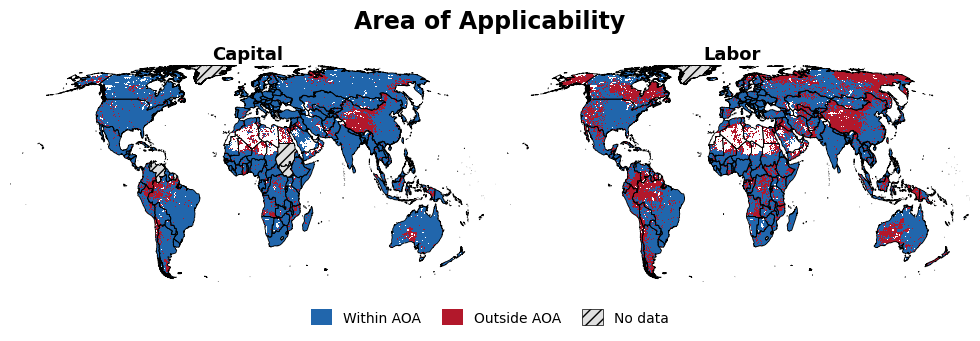

In [21]:
##### Global side-by-side map: AOA capital (left) vs labor (right)

# categorical colormap: 0 = outside AOA, 1 = within AOA
outside_color = "#b2182b"   # same red family as DI's high-dissimilarity end
within_color  = "#2166ac"   # same blue family as DI's low-dissimilarity end
no_data_color = "#e0e0e0"

aoa_cmap = mcolors.ListedColormap([outside_color, within_color])
aoa_cmap.set_bad(color='none')
aoa_norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5], aoa_cmap.N)

# --- Size figure to match the actual map aspect ratio ---
minx, miny, maxx, maxy = country_boundaries.total_bounds
map_aspect = (maxx - minx) / (maxy - miny)

panel_width = 5
panel_height = panel_width / map_aspect
fig_width = panel_width * 2
fig_height = panel_height * 1.5

fig, axes = plt.subplots(
    1, 2, figsize=(fig_width, fig_height), sharex=True, sharey=True,
    gridspec_kw={'wspace': 0.02}
)

panels = [
    (aoa_plot_capital, "has_capital_data", "Capital", axes[0]),
    (aoa_plot_labor,   "has_labor_data",   "Labor",   axes[1]),
]

for value_plot, data_flag_col, title, ax in panels:

    country_boundaries[country_boundaries[data_flag_col] == 0].plot(
        ax=ax, facecolor=no_data_color, edgecolor="none", hatch="///", zorder=1
    )
    country_boundaries.plot(
        ax=ax, facecolor="none", edgecolor="black", linewidth=0.6, zorder=2
    )
    im = value_plot.plot(
        ax=ax, cmap=aoa_cmap, norm=aoa_norm,
        add_colorbar=False, add_labels=False, zorder=0
    )

    ax.set_axis_off()
    ax.set_title(title, fontsize=13, weight='bold', pad=4)

axes[0].set_xlim(minx, maxx)
axes[0].set_ylim(miny, maxy)

fig.suptitle("Area of Applicability", fontsize=17, weight='bold', y=0.98)
fig.subplots_adjust(top=0.86, bottom=0.14, left=0.02, right=0.98)

# --- Categorical legend, centered underneath both panels ---
legend_handles = [
    Rectangle((0, 0), 1, 1, facecolor=within_color, edgecolor="none", label="Within AOA"),
    Rectangle((0, 0), 1, 1, facecolor=outside_color, edgecolor="none", label="Outside AOA"),
    Rectangle((0, 0), 1, 1, facecolor=no_data_color, edgecolor="black", linewidth=0.5,
              hatch="///", label="No data"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 0.02),
    handlelength=1.5,
    handleheight=1.5,
    columnspacing=1.5,
)

plt.show()
fig.savefig(f"{fd}/AOA_raster_capital_labor.png", dpi=300, bbox_inches='tight')

In [22]:
##### Prep production data (aligned to same grid as AOA/DI)

# here we just need a log-scaled, positive-only version aligned to AOA extent
production_capital = production.where(production > 0)
production_labor = production.where(production > 0)

log_prod_capital = np.log10(production_capital.squeeze())
log_prod_labor = np.log10(production_labor.squeeze())
# log_prod_capital = production_capital.squeeze()
# log_prod_labor = production_labor.squeeze()


# shared color scale across both panels — use robust percentiles, not raw min/max,
# so a handful of extreme outlier pixels don't wash out the rest of the scale
all_log_prod = np.concatenate([
    log_prod_capital.values[np.isfinite(log_prod_capital.values)],
    log_prod_labor.values[np.isfinite(log_prod_labor.values)],
])

vmin_log = np.percentile(all_log_prod, 1)
vmax_log = np.percentile(all_log_prod, 99)

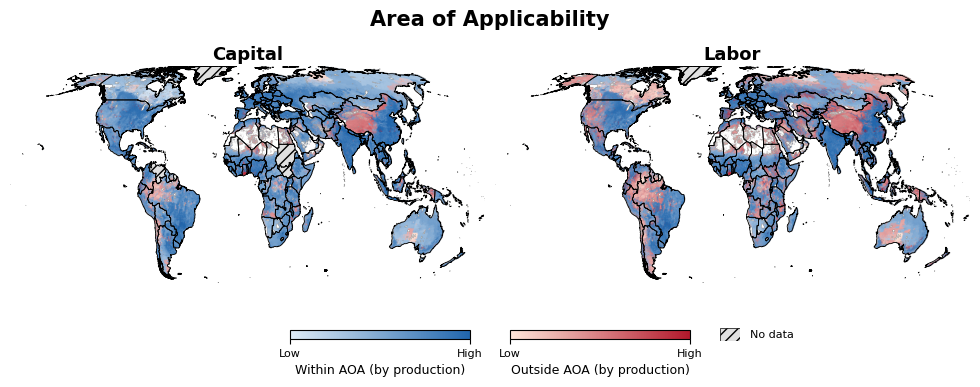

In [23]:
##### Global side-by-side map: AOA-by-production, capital (left) vs labor (right)

within_cmap = mcolors.LinearSegmentedColormap.from_list(
    "light_to_dark_blue", ["#deebf7", "#2166ac"]
)
outside_cmap = mcolors.LinearSegmentedColormap.from_list(
    "light_to_dark_red", ["#fee5d9", "#b2182b"]
)
no_data_color = "#e0e0e0"

norm = mcolors.Normalize(vmin=vmin_log, vmax=vmax_log)

def build_rgba(aoa_da, log_prod_da):
    """Combine AOA category + log production into a single RGBA image."""
    aoa = aoa_da.values
    prod = log_prod_da.values

    h, w = aoa.shape
    rgba = np.zeros((h, w, 4), dtype=float)

    valid = np.isfinite(aoa) & np.isfinite(prod)
    within = valid & (aoa == 1)
    outside = valid & (aoa == 0)

    rgba[within] = within_cmap(norm(prod[within]))
    rgba[outside] = outside_cmap(norm(prod[outside]))

    return rgba

rgba_capital = build_rgba(aoa_plot_capital, log_prod_capital)
rgba_labor = build_rgba(aoa_plot_labor, log_prod_labor)

# raster's OWN bounds — use for imshow extent, not the country boundary bounds
raster_left, raster_bottom, raster_right, raster_top = aoa_plot_capital.rio.bounds()

# --- Size figure to match the actual map aspect ratio (still from boundaries, fine for sizing) ---
minx, miny, maxx, maxy = country_boundaries.total_bounds
map_aspect = (maxx - minx) / (maxy - miny)

panel_width = 5
panel_height = panel_width / map_aspect
fig_width = panel_width * 2
fig_height = panel_height * 1.6

fig, axes = plt.subplots(
    1, 2, figsize=(fig_width, fig_height), sharex=True, sharey=True,
    gridspec_kw={'wspace': 0.02}
)

panels = [
    (rgba_capital, "has_capital_data", "Capital", axes[0]),
    (rgba_labor,   "has_labor_data",   "Labor",   axes[1]),
]

for rgba_img, data_flag_col, title, ax in panels:

    country_boundaries[country_boundaries[data_flag_col] == 0].plot(
        ax=ax, facecolor=no_data_color, edgecolor="none", hatch="///", zorder=1
    )
    country_boundaries.plot(
        ax=ax, facecolor="none", edgecolor="black", linewidth=0.6, zorder=2
    )

    ax.imshow(
        rgba_img,
        extent=[raster_left, raster_right, raster_bottom, raster_top],  # raster's own bounds
        origin="upper",
        zorder=0,
    )

    ax.set_axis_off()
    ax.set_title(title, fontsize=13, weight='bold', pad=4)

# axis zoom still uses country boundary bounds — separate from image placement
axes[0].set_xlim(minx, maxx)
axes[0].set_ylim(miny, maxy)

fig.suptitle("Area of Applicability", fontsize=15, weight='bold', y=0.98)
fig.subplots_adjust(top=0.86, bottom=0.20, left=0.02, right=0.98)

# --- Two colorbars underneath: Within AOA (blue) and Outside AOA (red), Low -> High only ---
sm_within = plt.cm.ScalarMappable(cmap=within_cmap, norm=norm)
sm_outside = plt.cm.ScalarMappable(cmap=outside_cmap, norm=norm)

cbar_ax_within = fig.add_axes([0.30, 0.08, 0.18, 0.025])
cbar_ax_outside = fig.add_axes([0.52, 0.08, 0.18, 0.025])

cbar_within = fig.colorbar(sm_within, cax=cbar_ax_within, orientation="horizontal")
cbar_outside = fig.colorbar(sm_outside, cax=cbar_ax_outside, orientation="horizontal")

for cbar, label in [(cbar_within, "Within AOA"), (cbar_outside, "Outside AOA")]:
    cbar.set_ticks([vmin_log, vmax_log])
    cbar.set_ticklabels(["Low", "High"])
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label(f"{label} (by production)", fontsize=9)

# --- No-data swatch ---
legend_ax = fig.add_axes([0.73, 0.075, 0.02, 0.035])
legend_ax.add_patch(Rectangle(
    (0, 0), 1, 1, facecolor=no_data_color, edgecolor="black",
    linewidth=0.5, hatch="///"
))
legend_ax.set_xlim(0, 1)
legend_ax.set_ylim(0, 1)
legend_ax.axis("off")
fig.text(0.76, 0.09, "No data", fontsize=8, va="center", ha="left")

plt.show()
fig.savefig(f"{fd}/AOA_production_capital_labor.png", dpi=300, bbox_inches='tight')